In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

path = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1"
files = glob.glob(f'{path}{os.sep}*.csv')

alldat = []
for i in files:
    tmp=pd.read_csv(i)
    cat = i.split(os.sep)[-1].split('_')[0]
    tmp['measure_type'] = cat
    alldat.append(tmp)
final = pd.concat(alldat)
final

,Target_ID,Classification,Z_Slice,Original_Y,Original_X,Corrected_Y,Corrected_X,Geodesic_Distance_um,Vol_voxels,Vol_um3,Max_Intensity,Sum_Intensity,Integrated_Density,Z_Slices_Count,Avg_Initial_Dendrite_Intensity,Barrier_um,Tolerance,Z_Search_Range,Dendrite_Length_um,measure_type
0,19,Spine,20,7,164,7,164,2.994932,567,1.984046,624,232588.0,232588.0,11,183.509077,1.2,0.45,10,77.780143,bla
1,21,Spine,33,140,142,139,142,1.296000,921,3.222763,544,289336.0,289336.0,16,183.509077,1.2,0.45,10,77.780143,bla
2,22,Spine,36,176,124,176,124,1.931963,860,3.009312,406,185597.0,185597.0,15,183.509077,1.2,0.45,10,77.780143,bla
3,3,Spine,33,211,148,210,149,1.304969,804,2.813357,807,407962.0,407962.0,12,183.509077,1.2,0.45,10,77.780143,bla
4,23,Spine,37,214,120,214,120,1.231389,317,1.109246,465,90416.0,90416.0,13,183.509077,1.2,0.45,10,77.780143,bla
5,5,Spine,35,254,141,254,141,1.420518,380,1.329696,479,107102.0,107102.0,12,183.509077,1.2,0.45,10,77.780143,bla
6,9,Spine,51,323,129,324,130,2.052000,753,2.634898,698,339175.0,339175.0,12,183.509077,1.2,0.45,10,77.780143,bla
7,10,Spine,51,338,98,337,97,1.404000,505,1.767096,845,291194.0,291194.0,11,183.509077,1.2,0.45,10,77.780143,bla
8,8,Spine,49,369,77,370,79,2.368625,1392,4.870886,507,418139.0,418139.0,14,183.509077,1.2,0.45,10,77.780143,bla
9,28,Spine,49,378,114,378,114,1.231389,266,0.930787,847,143021.0,143021.0,10,183.509077,1.2,0.45,10,77.780143,bla


In [ ]:
import statistics

measure = 'Vol_um3'
final.groupby(['Target_ID'])[measure].var()
pivot_df = final.pivot_table(
    index=['Target_ID'], 
    columns='measure_type', 
    values=measure
).reset_index()


variance_values = pivot_df[['bla', 'blm1', 'blm2']].var()
print(variance_values)

correlation_matrix = pivot_df[['bla', 'blm1', 'blm2']].corr()
print(correlation_matrix)
pivot_df
pivot_df[['bla', 'blm1', 'blm2']].var(axis=1)
df = pivot_df[['Target_ID','bla', 'blm1', 'blm2']]


measure_type
bla     1.233055
blm1    1.449684
blm2    1.464464
dtype: float64
measure_type       bla      blm1      blm2
measure_type                              
bla           1.000000  0.980551  0.979043
blm1          0.980551  1.000000  0.999966
blm2          0.979043  0.999966  1.000000


measure_type,Target_ID,bla,blm1,blm2
0,3,2.813357,2.813357,2.813357
1,5,1.329696,1.329696,1.329696
2,8,4.870886,4.870886,4.870886
3,9,2.634898,2.634898,2.634898
4,10,1.767096,1.767096,1.802088
5,17,1.802088,1.802088,1.802088
6,19,1.984046,1.984046,1.984046
7,21,3.222763,4.111560,4.111560
8,22,3.009312,3.009312,3.009312
9,23,1.109246,1.109246,1.109246


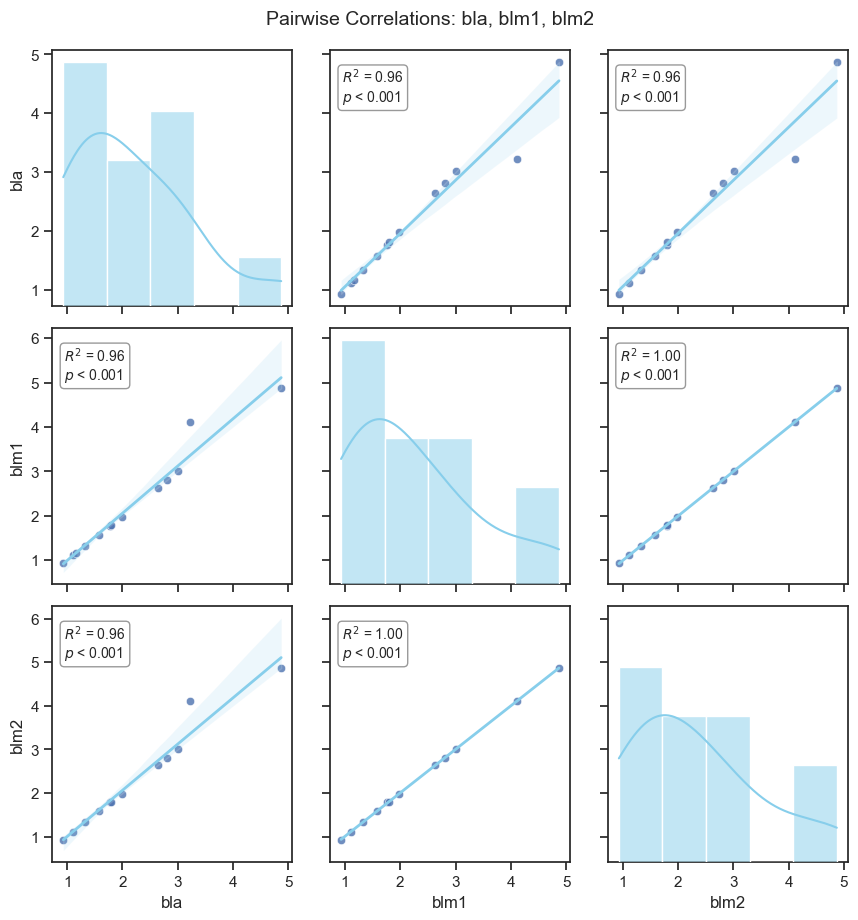

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np


# --- 2. CUSTOM FUNCTION TO ANNOTATE R² AND P-VALUE ---
def corr_func(x, y, **kwargs):
    """Calculates Pearson r, R², and p-value, then displays it on the plot."""
    # Drop rows where either x or y is NaN
    valid = pd.notna(x) & pd.notna(y)
    x_clean = x[valid]
    y_clean = y[valid]
    
    if len(x_clean) < 2:
        return
        
    r, p_val = stats.pearsonr(x_clean, y_clean)
    r2 = r ** 2
    
    # Format the text display
    text = f"$R^2$ = {r2:.2f}\n$p$ = {p_val:.3f}" if p_val >= 0.001 else f"$R^2$ = {r2:.2f}\n$p$ < 0.001"
    
    # Place text in the middle of the subplot
    ax = plt.gca()
    ax.annotate(text, xy=(0.05, 0.8), xycoords=ax.transAxes, 
                fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# --- 3. CREATE SEABORN PAIRPLOT ---
# Set aesthetic style
sns.set_theme(style="ticks")

# Create pairplot with regression lines on the lower/upper triangles
g = sns.PairGrid(df, vars=['bla', 'blm1', 'blm2'], height=3, despine=False)

# Map scatter plots with regression lines to the off-diagonal grids
g.map_offdiag(sns.scatterplot, alpha=0.8)
g.map_offdiag(sns.regplot, scatter=False, color='skyblue', line_kws={'linewidth': 2})

# Map histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='skyblue')

# Add R² and p-values to the upper or lower off-diagonal sections
g.map_offdiag(corr_func)

# Adjust layout and show
plt.suptitle("Pairwise Correlations: bla, blm1, blm2", y=1.02, fontsize=14)
plt.show()

In [ ]:
import tifffile
import numpy as np
tif_path = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder 1\bla.tif"
level = 170
window_width = 65

vmin = level - (window_width / 2)
vmax = level + (window_width / 2)
image = tifffile.imread(tif_path)
mip = np.max(image, axis=0)
# Display with matplotlib using the calculated window level bounds
plt.imshow(mip, cmap='gray', vmin=vmin, vmax=vmax)
# plt.colorbar(label='Intensity (Window Adjusted)')
# plt.figure(figsize=[2,6])
plt.plot(d['X'], d['Y'], '.')
for x, y, label in zip(d['X'], d['Y'], d['Target_ID']):
    plt.annotate(str(label), (x, y))
# plt.gca().invert_yaxis()